## Step 1: Load the snapshot

In [2]:
import pandas as pd

# Load your combined CSV
df = pd.read_csv("../data/raw/crypto_market_snapshot_2026-02-01.csv")

# Quick view
print(df.shape)
df.head()


(732, 18)


,timestamp,price,market_cap,volume,coin,symbol,name,market_cap_rank,circulating_supply,total_supply,max_supply,ath,atl,price_change_24h,price_change_percentage_24h,categories,bullish_votes_pct,bearish_votes_pct
0,2025-02-02 00:00:00,100674.787625,1.996424e+12,2.282778e+10,bitcoin,btc,Bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.682663,-6.62719,"Smart Contract Platform, Layer 1 (L1), FTX Hol...",53.62,46.38
1,2025-02-03 00:00:00,97568.316530,1.933691e+12,5.978423e+10,bitcoin,btc,Bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.682663,-6.62719,"Smart Contract Platform, Layer 1 (L1), FTX Hol...",53.62,46.38
2,2025-02-04 00:00:00,101466.860666,2.011121e+12,1.221640e+11,bitcoin,btc,Bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.682663,-6.62719,"Smart Contract Platform, Layer 1 (L1), FTX Hol...",53.62,46.38
3,2025-02-05 00:00:00,98118.439217,1.943535e+12,7.319669e+10,bitcoin,btc,Bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.682663,-6.62719,"Smart Contract Platform, Layer 1 (L1), FTX Hol...",53.62,46.38
4,2025-02-06 00:00:00,96582.886829,1.912585e+12,4.884896e+10,bitcoin,btc,Bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.682663,-6.62719,"Smart Contract Platform, Layer 1 (L1), FTX Hol...",53.62,46.38


## Step 2: check the data 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    732 non-null    object 
 1   price                        732 non-null    float64
 2   market_cap                   732 non-null    float64
 3   volume                       732 non-null    float64
 4   coin                         732 non-null    object 
 5   symbol                       732 non-null    object 
 6   name                         732 non-null    object 
 7   market_cap_rank              732 non-null    int64  
 8   circulating_supply           732 non-null    float64
 9   total_supply                 732 non-null    float64
 10  max_supply                   366 non-null    float64
 11  ath                          732 non-null    float64
 12  atl                          732 non-null    float64
 13  price_change_24h    

In [4]:
df.shape


(732, 18)

In [5]:
#check the missing values 
(df.isnull().sum())

timestamp                        0
price                            0
market_cap                       0
volume                           0
coin                             0
symbol                           0
name                             0
market_cap_rank                  0
circulating_supply               0
total_supply                     0
max_supply                     366
ath                              0
atl                              0
price_change_24h                 0
price_change_percentage_24h      0
categories                       0
bullish_votes_pct                0
bearish_votes_pct                0
dtype: int64

In [6]:
df.groupby("coin")["max_supply"].agg(
    non_null_count="count",
    total_rows="size",
    unique_values="nunique",
    value="first"
)

,non_null_count,total_rows,unique_values,value
coin,,,,
bitcoin,366,366,1,21000000.0
ethereum,0,366,0,NaN


* Bitcoin has a defined max_supply = 21,000,000
Ethereum has no fixed max supply which explaines why the max_supply column is null for ETH 
This is a semantic missingness, not a data quality issue. we will address this later in the feature engineering stage by setting a binary flag (1 is max supply exists else 0)

In [7]:
#check duplicates 
(df.duplicated().sum())

np.int64(0)

* i noticed that the features " price_change_24h" "price_change_percentage_24h" have an identical value every day, let's check this further 

In [8]:
df.groupby("coin")[["price_change_24h", "price_change_percentage_24h"]].nunique()


,price_change_24h,price_change_percentage_24h
coin,,
bitcoin,1,1
ethereum,1,1


* The features price_change_24h and price_change_percentage_24h provided by the CoinGecko coin info endpoint are snapshot values and remain constant across the historical dataset.

* To avoid data leakage and time misalignment, a time-consistent 24h price change will be computed later directly from historical prices as part of the feature engineering phase.

In [9]:
#data type check 
(df.dtypes)

timestamp                       object
price                          float64
market_cap                     float64
volume                         float64
coin                            object
symbol                          object
name                            object
market_cap_rank                  int64
circulating_supply             float64
total_supply                   float64
max_supply                     float64
ath                            float64
atl                            float64
price_change_24h               float64
price_change_percentage_24h    float64
categories                      object
bullish_votes_pct              float64
bearish_votes_pct              float64
dtype: object

* the timestamp feature is in object type we will convert it to datetime in the data preprocessing stage ( that is mandatory )

In [10]:
#identify which columns are likely categorical
(df.nunique())

timestamp                      367
price                          732
market_cap                     732
volume                         732
coin                             2
symbol                           2
name                             2
market_cap_rank                  2
circulating_supply               2
total_supply                     2
max_supply                       1
ath                              2
atl                              2
price_change_24h                 2
price_change_percentage_24h      2
categories                       2
bullish_votes_pct                2
bearish_votes_pct                2
dtype: int64

* i noticed that the "circulating_supply" feature is not historical but rather a snapshot value taken at the time of the data extraction, in the feature engineering stage we will compute a new feature " circulation_supply_history" using the marketcap and price features which will be much better then a static snapshot value 

* redundancy is identified for the features "coin","symbol","name" , in the data preprocessing part we will keep only 1 of them ( probably "coin")

* "categories" ex : Smart Contract Platform, Layer 1 (L1), FTX Holdings Recovery. This tells what the coin is, not how it behaves over time. we will drop it in the data preprocessing stage.

* ath ( all time high ) and atl ( all time low ) have a single unique value per coin captured at the time os the snapshot, they don't vary over time but we will keepthem to extract a new feature "distance from ath" and "distance from atl" in the feature engineering stage.

* the bullish_votes_pct bearish_votes_pct features are also snapshot values we will drop them in the EDA and ML/ deeplearning model but we will uclude them later when it comes to the chatbot development part as they reflect the market sentiment at a given time. 

In [11]:
#check the abnormal values (Price, market cap, volume must be > 0)
numeric_cols = ["price", "market_cap", "volume"]

for col in numeric_cols:
    print(col, (df[col] <= 0).sum())

price 0
market_cap 0
volume 0


## Step 3: Data preprocessing 

In [12]:
# round the values 
df["price"] = df["price"].round(2)
df["market_cap"] = df["market_cap"].round(0)
df["volume"] = df["volume"].round(0)
df["circulating_supply"] = df["circulating_supply"].round(0)
df["total_supply"] = df["total_supply"].round(0)
df["max_supply"] = df["max_supply"].round(0)
df["ath"] = df["ath"].round(2)
df["atl"] = df["atl"].round(2)
df["price_change_24h"] = df["price_change_24h"].round(2)
df["price_change_percentage_24h"] = df["price_change_percentage_24h"].round(2)
df["bullish_votes_pct"] = df["bullish_votes_pct"].round(2)
df["bearish_votes_pct"] = df["bearish_votes_pct"].round(2)

In [13]:
#Feature Selection Drop / Keep

cols_to_drop = [
    "bullish_votes_pct",
    "bearish_votes_pct",
    "categories",
    "symbol",
    "name"
]

df = df.drop(columns=cols_to_drop)


In [14]:
#Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])


In [15]:
df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,circulating_supply,total_supply,max_supply,ath,atl,price_change_24h,price_change_percentage_24h
0,2025-02-02,100674.79,1.996424e+12,2.282778e+10,bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.68,-6.63
1,2025-02-03,97568.32,1.933691e+12,5.978423e+10,bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.68,-6.63
2,2025-02-04,101466.86,2.011121e+12,1.221640e+11,bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.68,-6.63
3,2025-02-05,98118.44,1.943535e+12,7.319669e+10,bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.68,-6.63
4,2025-02-06,96582.89,1.912585e+12,4.884896e+10,bitcoin,1,19982656.0,19982656.0,21000000.0,126080.0,67.81,-5555.68,-6.63


In [16]:
df.index.is_monotonic_increasing
df.groupby("coin").size()


coin
bitcoin     366
ethereum    366
dtype: int64

## Step 4: Feature engineering 

* We will create a new feature that measures change in price from one day to the next, providing insights into the coin's daily performance and volatility​​ 
- log returns= ln(Price today/Price yesterday)
- this feature will replace the price_change_24h and price_change_percentage_24h features which are snapshot values and remain constant across the historical dataset.


In [17]:
# Drop existing column if it exists
if "log_return_1d" in df.columns:
    df = df.drop(columns=["log_return_1d"])

In [18]:
import numpy as np

df = df.sort_values(["coin", "timestamp"])

df["log_return_1d"] = (
    df.groupby("coin")["price"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


* we will create a new feature to mesure the rolling risk of the coin in a given period (7 days, 14 days) 
So instead of just knowing today s return, we know how unstable or risky the coin is in the last period. 


In [19]:
df["volatility_7d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=7)
    .std()
    .reset_index(level=0, drop=True)
)

df["volatility_14d"] = (
    df.groupby("coin")["log_return_1d"]
    .rolling(window=14)
    .std()
    .reset_index(level=0, drop=True)
)

* we will create a new feature for the RSI 14 day (relative strength index) which evaluates the overbought or oversold condition of a coin base on its recent price movements

In [20]:
window = 14

delta = df.groupby("coin")["price"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)
avg_loss = loss.groupby(df["coin"]).rolling(window).mean().reset_index(level=0, drop=True)

rs = avg_gain / avg_loss
df["rsi_14"] = 100 - (100 / (1 + rs))


* we will create a new feature for the market structure ratio 

- High value → high trading activity
- Low value → illiquid or sleepy market


In [21]:
df["volume_to_marketcap"] = df["volume"] / df["market_cap"]


* we will compute a new feature "circulating_supply_history" using the marketcap and price features which will replace the circulating_supply snapshot.

In [22]:
df["circulating_supply_history"] = df["market_cap"] / df["price"]

In [23]:
df["circulating_supply_history"] = df["circulating_supply_history"].round(0)

In [24]:
df = df.drop(columns=["circulating_supply"])

* we will add add 2 features ATH / ATL distance features : 
- Near ATH → bullish regime
- Near ATL → distress regime

In [25]:
df["distance_from_ath"] = (df["price"] - df["ath"]) / df["ath"]
df["distance_from_atl"] = (df["price"] - df["atl"]) / df["atl"]

* As the max supply feature has a semantic missingness ( it is null for coins that have no max supply like ETH) we will create a binary flag for the max supply feature 1 if there is max supply else 0
- this feature will replace the max supply feature 

In [26]:
#Create a binary flag for the max supply feature 1 if there is max supply else 0
df["has_max_supply"] = df["max_supply"].notna().astype(int)

In [28]:
cols_to_drop = [
    "total_supply",
    "max_supply",
    "price_change_24h",
    "price_change_percentage_24h",
]

df = df.drop(columns=cols_to_drop)


* Rolling features such as volatility and RSI require a historical window of 7–14 days. The 14 first rows per coin do not have sufficient data to compute these indicators and were therefore removed to ensure consistency across the database.

In [29]:
rolling_features = ["volatility_7d", "volatility_14d", "rsi_14"]
df = df.dropna(subset=rolling_features).reset_index(drop=True)

In [30]:
pd.set_option('display.max_columns', None)
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply
0,2025-02-16,97569.95,1.934308e+12,1.421531e+10,bitcoin,1,126080.0,67.81,0.000835,0.013479,0.019471,41.794291,0.007349,19824837.0,-0.226127,1437.872585,1
1,2025-02-17,96149.35,1.905012e+12,1.363479e+10,bitcoin,1,126080.0,67.81,-0.014667,0.014822,0.018009,45.882965,0.007157,19813054.0,-0.237394,1416.922873,1
2,2025-02-18,95776.16,1.898998e+12,2.532437e+10,bitcoin,1,126080.0,67.81,-0.003889,0.014250,0.013794,29.242476,0.013336,19827458.0,-0.240354,1411.419407,1
3,2025-02-19,95495.89,1.892702e+12,3.831113e+10,bitcoin,1,126080.0,67.81,-0.002931,0.012721,0.010890,37.675303,0.020242,19819724.0,-0.242577,1407.286241,1
4,2025-02-20,96554.87,1.914338e+12,2.770322e+10,bitcoin,1,126080.0,67.81,0.011028,0.009996,0.010623,49.862145,0.014471,19826425.0,-0.234178,1422.903112,1


## Step 5: Production ready pipeline

* In this section we will create a production ready pipeline that will take raw CoinGecko data, apply the previous same preprocessing and feature engineering and always output exactly our final dataset with:same columns , same order, same feature definitions .
* That will allow as later to extract row data from coingecko and use it as prediction input for our Ml model 

In [31]:
#imports 
import pandas as pd
import numpy as np

In [33]:
#Preprocessing function (rounding, typing, sorting, drops)
def preprocess_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Convert timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Sort (CRITICAL for time-series)
    df = df.sort_values(["coin", "timestamp"]).reset_index(drop=True)

    # Rounding (as you decided)
    df["price"] = df["price"].round(2)
    df["market_cap"] = df["market_cap"].round(0)
    df["volume"] = df["volume"].round(0)
    df["circulating_supply"] = df["circulating_supply"].round(0)
    df["total_supply"] = df["total_supply"].round(0)
    df["max_supply"] = df["max_supply"].round(0)
    df["ath"] = df["ath"].round(2)
    df["atl"] = df["atl"].round(2)
    df["price_change_24h"] = df["price_change_24h"].round(2)
    df["price_change_percentage_24h"] = df["price_change_percentage_24h"].round(2)
    df["bullish_votes_pct"] = df["bullish_votes_pct"].round(2)
    df["bearish_votes_pct"] = df["bearish_votes_pct"].round(2)

    # Drop unused categorical / snapshot columns
    df = df.drop(
        columns=[
            "bullish_votes_pct",
            "bearish_votes_pct",
            "categories",
            "symbol",
            "name",
        ],
        errors="ignore",
    )

    return df


In [34]:
#Feature engineering function
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Log return (SAFE version)
    df["log_return_1d"] = (
        df.groupby("coin")["price"]
        .transform(lambda x: np.log(x / x.shift(1)))
    )

    # Volatility (log returns)
    df["volatility_7d"] = (
        df.groupby("coin")["log_return_1d"]
        .rolling(window=7)
        .std()
        .reset_index(level=0, drop=True)
    )

    df["volatility_14d"] = (
        df.groupby("coin")["log_return_1d"]
        .rolling(window=14)
        .std()
        .reset_index(level=0, drop=True)
    )

    # RSI 14
    window = 14
    delta = df.groupby("coin")["price"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = (
        gain.groupby(df["coin"])
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    avg_loss = (
        loss.groupby(df["coin"])
        .rolling(window)
        .mean()
        .reset_index(level=0, drop=True)
    )

    rs = avg_gain / avg_loss
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # Volume / Market cap
    df["volume_to_marketcap"] = df["volume"] / df["market_cap"]

    # Circulating supply history
    df["circulating_supply_history"] = (df["market_cap"] / df["price"]).round(0)

    # Distance from ATH / ATL
    df["distance_from_ath"] = (df["price"] - df["ath"]) / df["ath"]
    df["distance_from_atl"] = (df["price"] - df["atl"]) / df["atl"]

    # Max supply binary flag
    df["has_max_supply"] = df["max_supply"].notna().astype(int)

    # Drop snapshot circulating supply
    df = df.drop(columns=["circulating_supply"], errors="ignore")

    return df


In [35]:
# Final dataset column order
FINAL_COLUMNS = [
    "timestamp",
    "price",
    "market_cap",
    "volume",
    "coin",
    "market_cap_rank",
    "total_supply",
    "max_supply",
    "ath",
    "atl",
    "price_change_24h",
    "price_change_percentage_24h",
    "log_return_1d",
    "volatility_7d",
    "volatility_14d",
    "rsi_14",
    "volume_to_marketcap",
    "circulating_supply_history",
    "distance_from_ath",
    "distance_from_atl",
    "has_max_supply",
]

def finalize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop NaNs from rolling features
    rolling_features = ["volatility_7d", "volatility_14d", "rsi_14"]
    df = df.dropna(subset=rolling_features).reset_index(drop=True)

    # Enforce final column order
    df = df[FINAL_COLUMNS]

    return df


In [36]:
# Production ready pipeline
def coingecko_preprocessing_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    df = preprocess_raw_data(df)
    df = engineer_features(df)
    df = finalize_dataset(df)
    return df


## Step 6: EDA and visualization 

this EDA section should help us answer:

* What does price actually look like over time?

* Which features move with price vs against it?

* Which features are redundant?

* Which features are informative for short-term prediction (LSTM)?

* Are there regime effects? (bull vs bear signals)

since it's a time series data we will care more about:

* relationships over time

* relative changes

* leading indicators

In [37]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   704 non-null    datetime64[ns]
 1   price                       704 non-null    float64       
 2   market_cap                  704 non-null    float64       
 3   volume                      704 non-null    float64       
 4   coin                        704 non-null    object        
 5   market_cap_rank             704 non-null    int64         
 6   ath                         704 non-null    float64       
 7   atl                         704 non-null    float64       
 8   log_return_1d               704 non-null    float64       
 9   volatility_7d               704 non-null    float64       
 10  volatility_14d              704 non-null    float64       
 11  rsi_14                      704 non-null    float64       

,count,mean,min,25%,50%,75%,max,std
timestamp,704,2025-08-10 11:56:12.923295488,2025-02-16 00:00:00,2025-05-14 18:00:00,2025-08-10 12:00:00,2025-11-06 06:00:00,2026-02-01 01:48:03,NaN
price,704.0,51972.459915,1471.36,2966.375,40579.16,103316.6025,124773.51,49735.631248
market_cap,704.0,1188496728329.956055,177496121146.0,357982092378.5,1048929753463.5,2055021594278.5,2486073086655.0,842158786806.128174
volume,704.0,35676911811.715912,5148626529.0,20488242835.75,30916403840.0,45912581551.0,151002213090.0,20859465258.69873
market_cap_rank,704.0,1.5,1.0,1.0,1.5,2.0,2.0,0.500355
ath,704.0,65513.025,4946.05,4946.05,65513.025,126080.0,126080.0,60610.037199
atl,704.0,34.12,0.43,0.43,34.12,67.81,67.81,33.713953
log_return_1d,704.0,-0.000471,-0.158573,-0.0143,-0.000126,0.012639,0.193844,0.031878
volatility_7d,704.0,0.027569,0.005567,0.016185,0.0238,0.034219,0.088533,0.015974
volatility_14d,704.0,0.028526,0.007965,0.018602,0.025833,0.035103,0.070733,0.013598


In [40]:
df.shape

(704, 17)

In [41]:
# Compute timestamp differences per coin
df["time_diff"] = df.groupby("coin")["timestamp"].diff()

# Show rows where diff is NOT 1 day and NOT the first row (NaT)
bad_rows = df[
    df["time_diff"].notna() &
    (df["time_diff"] != pd.Timedelta(days=1))
]

bad_rows


,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply,time_diff
351,2026-02-01 01:47:35,78270.51,1.565516e+12,8.032431e+10,bitcoin,1,126080.00,67.81,-0.005801,0.032519,0.026118,16.423510,0.051309,20001356.0,-0.379200,1153.262056,1,0 days 01:47:35
703,2026-02-01 01:48:03,2435.53,2.938406e+11,4.986940e+10,ethereum,2,4946.05,0.43,-0.003443,0.051081,0.041452,18.533265,0.169716,120647515.0,-0.507581,5663.023256,0,0 days 01:48:03


* for time series modelling we need to have the same time step for all the rows ( daily in our case) that s why we are going to drop the 2 lines of the data loding date as they are not complete day data

In [42]:
df = df.drop(bad_rows.index).reset_index(drop=True)

In [50]:
df.head()

,timestamp,price,market_cap,volume,coin,market_cap_rank,ath,atl,log_return_1d,volatility_7d,volatility_14d,rsi_14,volume_to_marketcap,circulating_supply_history,distance_from_ath,distance_from_atl,has_max_supply,time_diff
0,2025-02-16,97569.95,1.934308e+12,1.421531e+10,bitcoin,1,126080.0,67.81,0.000835,0.013479,0.019471,41.794291,0.007349,19824837.0,-0.226127,1437.872585,1,NaT
1,2025-02-17,96149.35,1.905012e+12,1.363479e+10,bitcoin,1,126080.0,67.81,-0.014667,0.014822,0.018009,45.882965,0.007157,19813054.0,-0.237394,1416.922873,1,1 days
2,2025-02-18,95776.16,1.898998e+12,2.532437e+10,bitcoin,1,126080.0,67.81,-0.003889,0.014250,0.013794,29.242476,0.013336,19827458.0,-0.240354,1411.419407,1,1 days
3,2025-02-19,95495.89,1.892702e+12,3.831113e+10,bitcoin,1,126080.0,67.81,-0.002931,0.012721,0.010890,37.675303,0.020242,19819724.0,-0.242577,1407.286241,1,1 days
4,2025-02-20,96554.87,1.914338e+12,2.770322e+10,bitcoin,1,126080.0,67.81,0.011028,0.009996,0.010623,49.862145,0.014471,19826425.0,-0.234178,1422.903112,1,1 days


In [55]:
# Basic statistics per coin
basic_stats = df.groupby("coin")[["price", "market_cap", "volume", 
                                  "log_return_1d", "volatility_7d", "rsi_14"]].describe()
print(basic_stats)


          price                                                              \
          count           mean           std       min       25%        50%   
coin                                                                          
bitcoin   351.0  100954.841652  12367.246074  76329.09  89224.49  103396.08   
ethereum  351.0    3056.285812    880.494263   1471.36   2490.31    2966.77   

                                market_cap                              \
                 75%        max      count          mean           std   
coin                                                                     
bitcoin   111271.805  124773.51      351.0  2.009576e+12  2.465354e+11   
ethereum    3802.045    4829.23      351.0  3.688921e+11  1.063047e+11   

                                                                  \
                   min           25%           50%           75%   
coin                                                               
bitcoin   1.515042e+12  1.782

** Price :

Bitcoin: Mean ≈ 100,955 USD, Std ≈ 12,367, Min ≈ 76,329, Max ≈ 124,774
Ethereum: Mean ≈ 3,056 USD, Std ≈ 880, Min ≈ 1,471, Max ≈ 4,829 

- Bitcoin is roughly 33x more expensive than Ethereum -> large scale difference → we will need normalization before feeding to ML/LSTM.


** Market cap: 

Bitcoin: Mean ≈ 2.01T, Std ≈ 0.25T, Max ≈ 2.21T
Ethereum: Mean ≈ 0.37T, Std ≈ 0.11T, Max ≈ 0.46T
- Bitcoin dominates market cap as expected (~5x Ethereum) and the std deviation relative to the mean shows Ethereum is more volatile

** RSI 14 day:

Mean ≈ 51 for both coins → roughly neutral (50 is the midpoint).
Max Bitcoin ≈ 88, Max Ethereum ≈ 99 → Ethereum can get extremely overbought.
Min Bitcoin ≈ 16, Min Ethereum ≈ 15 → Both can get oversold.

- RSI shows both coins reach extremes, but Ethereum more often hits the very high/low zones could signal strong trend moves

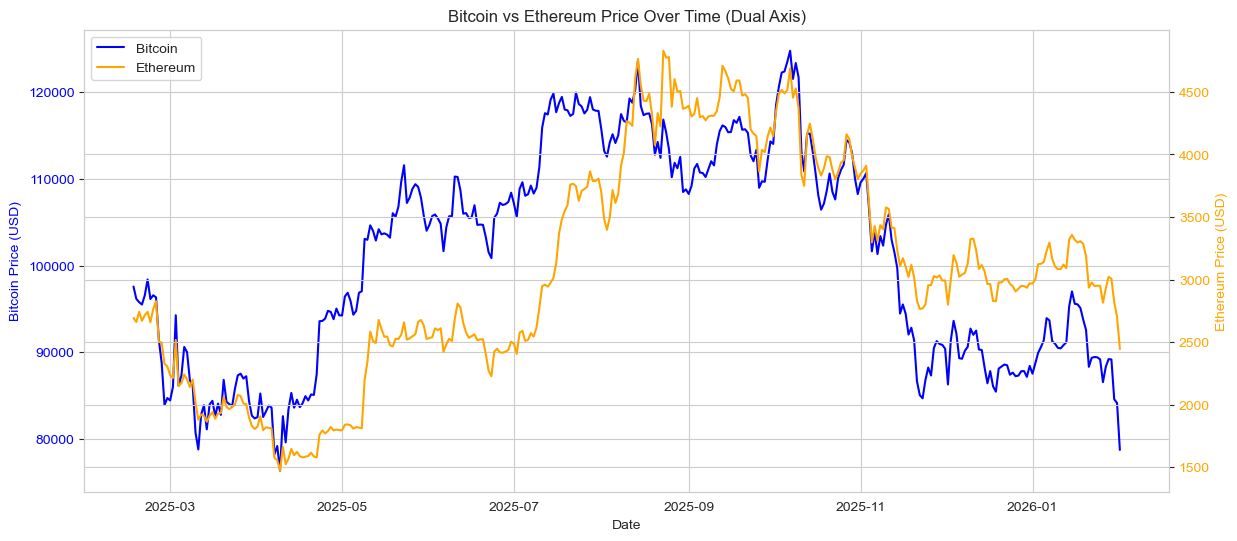

In [57]:
#price over time 
plt.figure(figsize=(14,6))

# Separate data
btc = df[df['coin'] == 'bitcoin']
eth = df[df['coin'] == 'ethereum']

# Plot Bitcoin
ax = plt.gca()
ax.plot(btc['timestamp'], btc['price'], color='blue', label='Bitcoin')
ax.set_ylabel('Bitcoin Price (USD)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# Plot Ethereum on secondary axis
ax2 = ax.twinx()
ax2.plot(eth['timestamp'], eth['price'], color='orange', label='Ethereum')
ax2.set_ylabel('Ethereum Price (USD)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Bitcoin vs Ethereum Price Over Time (Dual Axis)")
ax.set_xlabel("Date")

# Legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()



- Co-movement: Many price spikes in Bitcoin coincide with similar spikes in Ethereum suggesting a correlation between the two coins, likely due to market sentiment and shared investor base (btc movement could serve as a predictive feature for Ethereum in ML models and vice versa)
- Volatility: Ethereum's price appears more jagged compared to Bitcoin confirming its higher volatility



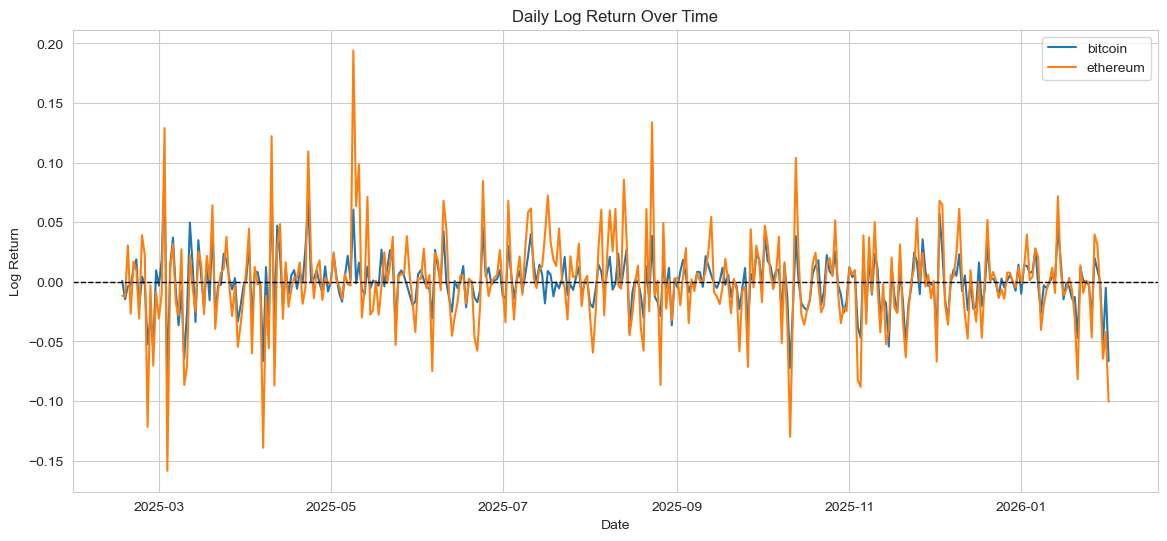

In [58]:
# Daily Log Return Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['log_return_1d'], label=coin)

plt.axhline(0, color='black', linestyle='--', linewidth=1)  # zero line
plt.title("Daily Log Return Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.show()


- Log Return:

Ethereum shows larger daily swings (both positive and negative) compared to Bitcoin, confirming higher daily volatility.
Spikes indicate sudden market movements potential risk periods or trading opportunities.

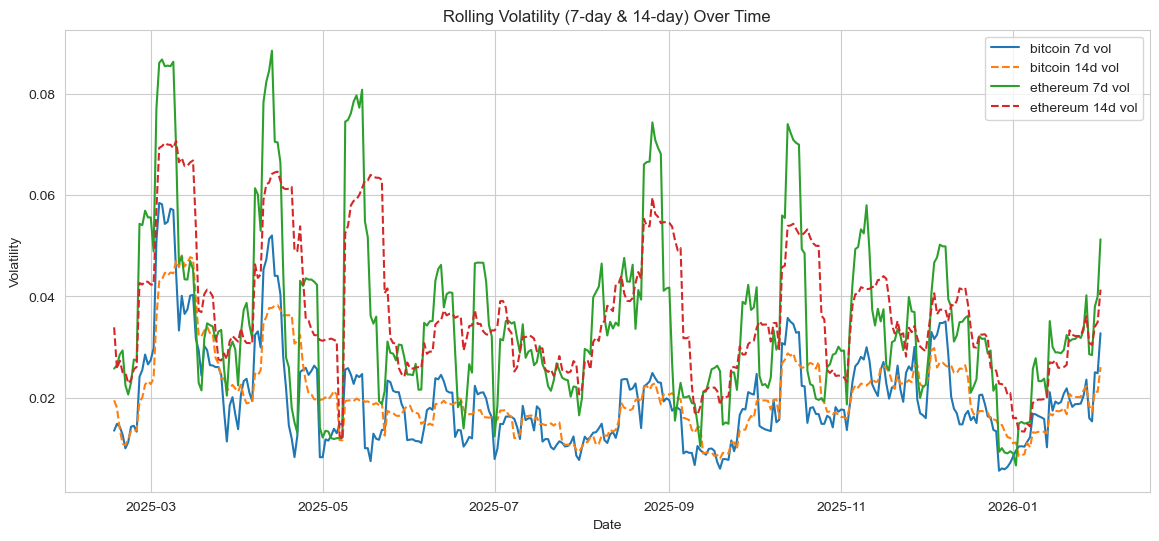

In [ ]:
# Rolling Volatility Over Time

plt.figure(figsize=(14,6))

for coin in df['coin'].unique():
    coin_df = df[df['coin'] == coin]
    plt.plot(coin_df['timestamp'], coin_df['volatility_7d'], label=f'{coin} 7d vol')
    plt.plot(coin_df['timestamp'], coin_df['volatility_14d'], label=f'{coin} 14d vol', linestyle='--')

plt.title("Rolling Volatility (7-day & 14-day) Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()


- Rolling Volatility:

Bitcoin’s rolling volatility is relatively stable, Ethereum’s volatility fluctuates more widely.
7day vs 14day: shorter windows capture quick spikes, longer windows smooth the noise and show trend volatility
Log returns and rolling volatility are key inputs for LSTM models because they represent normalized price movement and risk dynamics..

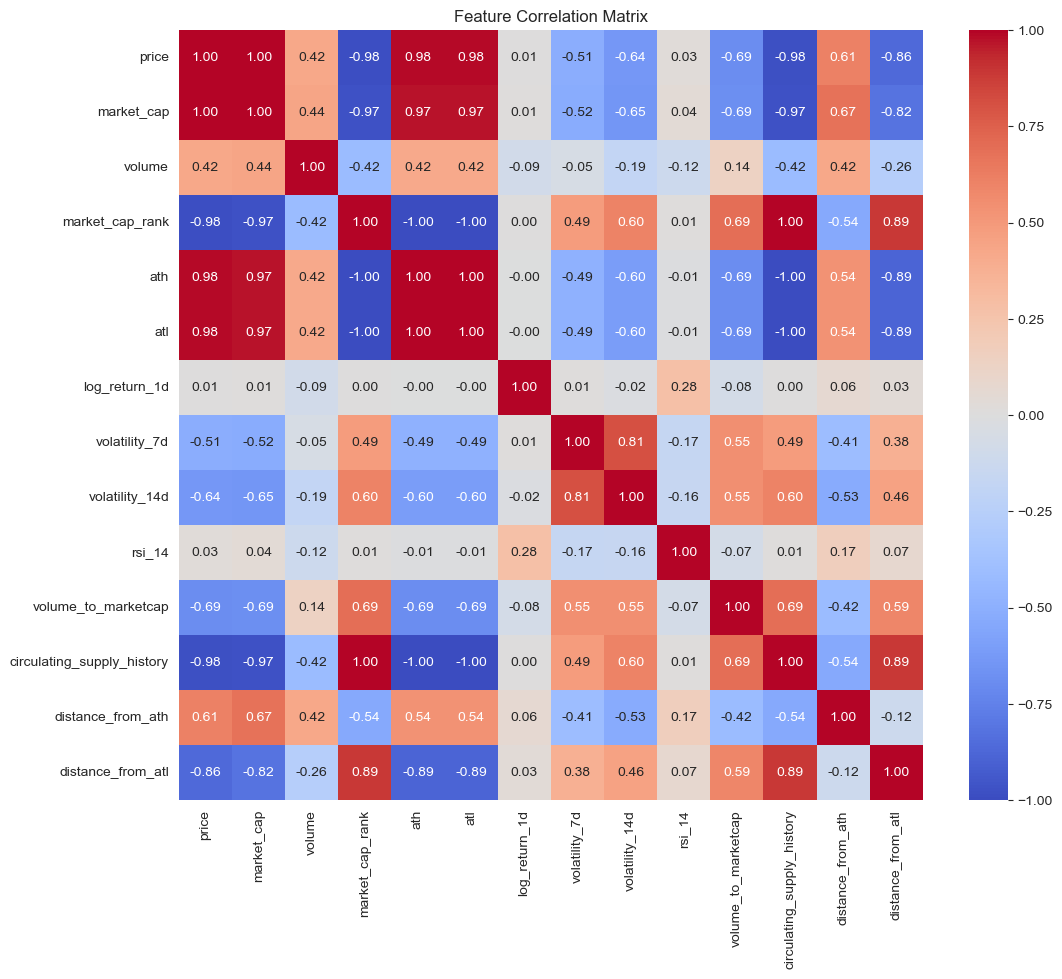

In [60]:
# correlation heat map 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

# Drop non-numeric/time columns
numeric_df = df.drop(columns=["timestamp", "coin", "has_max_supply", "time_diff"])

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


Volatility and Risk Features:

- volatility_7d and volatility_14d are highly correlated with each other ( for our ML/LSTM one of them wil be sufficient), as expected both show a slight negative correlation with price indicating higher volatility often occurs during price dips

- log_return_1d is mostly uncorrelated with price, which is normal because it represents daily changes, not the absolute level

- circulating_supply_history = market_cap / price → high correlation with price (almost 1) should be droped from ML/LSTM

- distance_from_ath is strongly negatively correlated with price which makes sense: as price approaches its all time high, this distance decreases

- distance_from_atl is positively correlated with price: as price moves away from the all time low, this distance increases 
- the 2 features are mirror-like metrics we can keep only one for Ml/LSTM

- has_max_supply is mostly uncorrelated with price, may not add much predictive power for daily price unless using multi-coin data. Could test inclusion in ML/LSTM 

- rsi_14 has a weak positive correlation with price, reflecting that higher prices often coincide with overbought conditions.